# What genes could promote stalled erythroid maturation unique to the T21/GATA1s condition in "HPC - Ery bias" cells

To test, consider:

The top erythroid lineage driver genes
- a. q-value < 0.1
- b. positively correlated with erythroid lineage.

Using the GLM results, differentially expressed in T21/GATA1s “HPC - Ery bias” cells
- a. q-value < 0.01
- b. conditionT21:genotypeGATA1s interaction coefficient > 0 (this will help filter out genes that are downregulated in T21/GATA1s compared to T21/wtGATA1)

## Import packages & data

In [ ]:
import os
import numpy as np
import pandas as pd
import scanpy as sc
import scvelo as scv
import anndata as ad
import cellrank as cr
from cellrank.kernels import CytoTRACEKernel
import matplotlib.pyplot as plt
import seaborn as sns
import scipy
from scipy.stats.mstats import mquantiles
from scipy.cluster.hierarchy import fcluster
import warnings
warnings.filterwarnings('ignore')

# cr.settings.verbosity = 2
# sc.settings.set_figure_params(frameon=False, dpi=100)
# scv.logging.print_version()
# scv.settings.verbosity = 3  # show errors(0), warnings(1), info(2), hints(3)
# scv.settings.presenter_view = True  # set max width size for presenter view
# scv.set_figure_params()  # for beautified visualization

/tmp/ipykernel_3988741/3908538346.py:3: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


## Load data

The dataset contains 3 time-points (days 7, 9, & 11) of iPSCs cell development for wtGATA and GATA1s genotype mutation samples

In [ ]:
# Load anndata file converted from Seurat integrated object
adata = scv.read("../seurat_objects/timecourse-d7911-renamed-merged.h5ad")
adata

AnnData object with n_obs × n_vars = 148750 × 29918
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'percent.mt', 'seurat_clusters', 'integrated_snn_res.0.4', 'cell_type', 'S.Score', 'G2M.Score', 'Phase', 'barcode', 'condition', 'genotype', 'time', 'sample_batch', 'batch', 'initial_size_unspliced', 'initial_size_spliced', 'initial_size'
    var: 'Accession', 'Chromosome', 'End', 'Start', 'Strand'
    uns: 'cell_type_colors', 'time_colors'
    obsm: 'X_pca', 'X_umap_integrated', 'X_umap_merged'
    layers: 'ambiguous', 'matrix', 'spliced', 'unspliced'

## Preprocess data

Basic preprocessing of the data before applying the CytoTRACE kernel

In [ ]:
# filter, normalize total counts and log-transform
sc.pp.filter_genes(adata, min_cells = 3)
scv.pp.normalize_per_cell(adata, enforce=True)
sc.pp.log1p(adata)

# hvg annotation
sc.pp.highly_variable_genes(adata, n_top_genes = 6000)
print(f"This detected {adata.var['highly_variable'].sum()} highly variable genes. ")
adata

Normalized count data: X, spliced, unspliced.
This detected 6000 highly variable genes. 


AnnData object with n_obs × n_vars = 148750 × 29918
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'percent.mt', 'seurat_clusters', 'integrated_snn_res.0.4', 'cell_type', 'S.Score', 'G2M.Score', 'Phase', 'barcode', 'condition', 'genotype', 'time', 'sample_batch', 'batch', 'initial_size_unspliced', 'initial_size_spliced', 'initial_size', 'n_counts'
    var: 'Accession', 'Chromosome', 'End', 'Start', 'Strand', 'n_cells', 'gene_count_corr', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'cell_type_colors', 'time_colors', 'log1p', 'hvg'
    obsm: 'X_pca', 'X_umap_integrated', 'X_umap_merged'
    layers: 'ambiguous', 'matrix', 'spliced', 'unspliced'

CytoTRACE uses imputed gene expression to calculate the score of differentiation potential. Here, we use use scvelo.pp.moments() for imputation. We’re copying our X matrix into the layers because that’s where moments() expects to find counts for imputation

In [ ]:
adata.layers["spliced"] = adata.X
adata.layers["unspliced"] = adata.X
scv.pp.moments(adata, n_pcs=30, n_neighbors=50)

computing neighbors
    finished (0:01:43) --> added 
    'distances' and 'connectivities', weighted adjacency matrices (adata.obsp)
computing moments based on connectivities
    finished (0:10:39) --> added 
    'Ms' and 'Mu', moments of un/spliced abundances (adata.layers)


## Compute the CytoTRACE score and transition matrix

In [ ]:
warnings.filterwarnings('ignore')
ctk = CytoTRACEKernel(adata).compute_cytotrace()
ctk.compute_transition_matrix(threshold_scheme="soft", nu=0.5)
adata.obs.columns

  0%|          | 0/148750 [00:00<?, ?cell/s]

Index(['orig.ident', 'nCount_RNA', 'nFeature_RNA', 'percent.mt',
       'seurat_clusters', 'integrated_snn_res.0.4', 'cell_type', 'S.Score',
       'G2M.Score', 'Phase', 'barcode', 'condition', 'genotype', 'time',
       'sample_batch', 'batch', 'initial_size_unspliced',
       'initial_size_spliced', 'initial_size', 'n_counts', 'ct_score',
       'ct_pseudotime', 'ct_num_exp_genes'],
      dtype='object')

## Computing terminal States

In [ ]:
## Initialize an estimator to compute initial and terminal states
g = cr.estimators.GPCCA(ctk)
print(g)

GPCCA[kernel=CytoTRACEKernel[n=148750], initial_states=None, terminal_states=None]


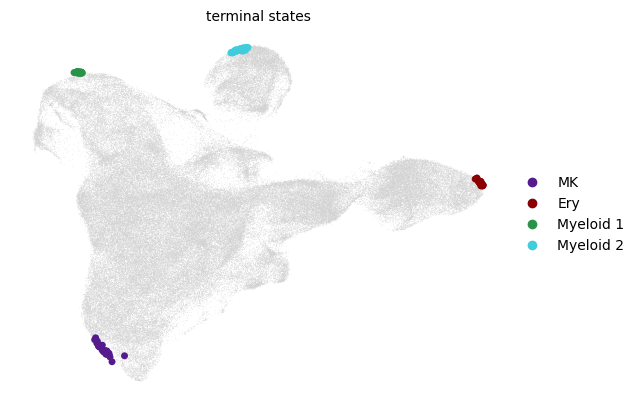

AnnData object with n_obs × n_vars = 148750 × 29918
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'percent.mt', 'seurat_clusters', 'integrated_snn_res.0.4', 'cell_type', 'S.Score', 'G2M.Score', 'Phase', 'barcode', 'condition', 'genotype', 'time', 'sample_batch', 'batch', 'initial_size_unspliced', 'initial_size_spliced', 'initial_size', 'n_counts', 'ct_score', 'ct_pseudotime', 'ct_num_exp_genes', 'macrostates_fwd', 'term_states_fwd', 'term_states_fwd_probs'
    var: 'Accession', 'Chromosome', 'End', 'Start', 'Strand', 'n_cells', 'gene_count_corr', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'ct_gene_corr', 'ct_correlates'
    uns: 'cell_type_colors', 'time_colors', 'log1p', 'hvg', 'neighbors', 'ct_params', 'schur_matrix_fwd', 'eigendecomposition_fwd', 'macrostates_fwd_colors', 'coarse_fwd', 'term_states_fwd_colors'
    obsm: 'X_pca', 'X_umap_integrated', 'X_umap_merged', 'schur_vectors_fwd', 'macrostates_fwd_memberships', 'term_states_fwd_memberships'
    layer

In [ ]:
# Compute microstates based on the real Shur decomposition
warnings.filterwarnings('ignore')
g.compute_schur(n_components=20)
g.compute_macrostates(n_states=7, n_cells=30, cluster_key="cell_type")
g.set_terminal_states(states=["MK", "Ery", "Myeloid_1", "Myeloid_2"], allow_overlap=True)
g.plot_macrostates(which="terminal", basis="umap_integrated",  legend_loc="right", s=100, discrete=True)
adata

## Estimating fate probabilities and computering driver genes for all terminal trajectories

In [ ]:
warnings.filterwarnings('ignore')
g.compute_fate_probabilities(tol=1e-20)
driver_genes = g.compute_lineage_drivers()

  0%|          | 0/4 [00:00<?, ?/s]

Add latent time from scVelo to the metadata (adata.obs) to use for pseudotemporalordering with CellRank's fate probabilities to visualize each gene's expression along specific trajectories (intial to termiates states along a lineage). CellRank's ct_pseudotime a bit more re-oreinting in order to obtain the correct expression cascades of sequential activation.

In [ ]:
latent_time = pd.read_csv("../results/timecourse/timecourse-d7911-renamed-latent-time.csv.gz")[["barcode", "latent_time"]]
latent_time
adata.obs = adata.obs.merge(latent_time, on='barcode', how='left')
adata

AnnData object with n_obs × n_vars = 148750 × 29918
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'percent.mt', 'seurat_clusters', 'integrated_snn_res.0.4', 'cell_type', 'S.Score', 'G2M.Score', 'Phase', 'barcode', 'condition', 'genotype', 'time', 'sample_batch', 'batch', 'initial_size_unspliced', 'initial_size_spliced', 'initial_size', 'n_counts', 'ct_score', 'ct_pseudotime', 'ct_num_exp_genes', 'macrostates_fwd', 'term_states_fwd', 'term_states_fwd_probs', 'latent_time'
    var: 'Accession', 'Chromosome', 'End', 'Start', 'Strand', 'n_cells', 'gene_count_corr', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'ct_gene_corr', 'ct_correlates'
    uns: 'cell_type_colors', 'time_colors', 'log1p', 'hvg', 'neighbors', 'ct_params', 'schur_matrix_fwd', 'eigendecomposition_fwd', 'macrostates_fwd_colors', 'coarse_fwd', 'term_states_fwd_colors'
    obsm: 'X_pca', 'X_umap_integrated', 'X_umap_merged', 'schur_vectors_fwd', 'macrostates_fwd_memberships', 'term_states_fwd_members

## Ery lineage diver genes and  MAST "HPC - Ery bias" DEGs

In [ ]:
# lineage drivers
adata_hpc = adata[adata.obs["cell_type"]== "HPCs"]
adata_hpc

View of AnnData object with n_obs × n_vars = 13351 × 29918
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'percent.mt', 'seurat_clusters', 'integrated_snn_res.0.4', 'cell_type', 'S.Score', 'G2M.Score', 'Phase', 'barcode', 'condition', 'genotype', 'time', 'sample_batch', 'batch', 'initial_size_unspliced', 'initial_size_spliced', 'initial_size', 'n_counts', 'ct_score', 'ct_pseudotime', 'ct_num_exp_genes', 'macrostates_fwd', 'term_states_fwd', 'term_states_fwd_probs', 'latent_time'
    var: 'Accession', 'Chromosome', 'End', 'Start', 'Strand', 'n_cells', 'gene_count_corr', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'ct_gene_corr', 'ct_correlates'
    uns: 'cell_type_colors', 'time_colors', 'log1p', 'hvg', 'neighbors', 'ct_params', 'schur_matrix_fwd', 'eigendecomposition_fwd', 'macrostates_fwd_colors', 'coarse_fwd', 'term_states_fwd_colors'
    obsm: 'X_pca', 'X_umap_integrated', 'X_umap_merged', 'schur_vectors_fwd', 'macrostates_fwd_memberships', 'term_states_fwd_

In [ ]:
term_probs = pd.DataFrame(adata_hpc.obsm['term_states_fwd_memberships'],
                          columns=adata_hpc.obsm['term_states_fwd_memberships'].names,
                          index=adata_hpc.obs_names)
term_probs['Ery'].quantile(np.arange(0,1,0.1))

0.0    0.000000
0.1    0.006877
0.2    0.007848
0.3    0.008528
0.4    0.009568
0.5    0.011103
0.6    0.013004
0.7    0.015197
0.8    0.018749
0.9    0.025960
Name: Ery, dtype: float64

In [ ]:
thresh = term_probs['Ery'].quantile(0.5)
prob_test = term_probs.apply(lambda x: x['Ery'] > thresh, axis=1)
adata_ery_bc = term_probs.index[prob_test].values.tolist()
print(len(adata_ery_bc))
other_ery_bc = adata.obs_names[adata.obs['cell_type'].isin(['Ery', 'HPC - Ery bias'])].tolist()
adata_ery_bc.extend(other_ery_bc)
print(len(other_ery_bc))

6675
32004


In [ ]:
adata.varm['terminal_lineage_drivers']

,MK_corr,MK_pval,MK_qval,MK_ci_low,MK_ci_high,Ery_corr,Ery_pval,Ery_qval,Ery_ci_low,Ery_ci_high,Myeloid_1_corr,Myeloid_1_pval,Myeloid_1_qval,Myeloid_1_ci_low,Myeloid_1_ci_high,Myeloid_2_corr,Myeloid_2_pval,Myeloid_2_qval,Myeloid_2_ci_low,Myeloid_2_ci_high
AL627309.1,6.794094e-03,8.783480e-03,1.639021e-02,0.001712,0.011876,-0.008097,1.790353e-03,3.915194e-03,-0.013178,-0.003015,-0.000534,8.368352e-01,8.832766e-01,-0.005616,0.004548,-0.006602,1.088267e-02,2.753616e-02,-0.011684,-0.001521
AL627309.5,6.317049e-03,1.483529e-02,2.680531e-02,0.001235,0.011399,-0.007621,3.287699e-03,6.977468e-03,-0.012703,-0.002540,-0.000411,8.741678e-01,9.104735e-01,-0.005492,0.004671,-0.006242,1.606064e-02,3.934994e-02,-0.011324,-0.001160
LINC01409,7.596559e-04,7.695358e-01,8.214862e-01,-0.004322,0.005841,-0.020508,2.563573e-15,1.038691e-14,-0.025587,-0.015428,0.002372,3.602214e-01,4.834734e-01,-0.002710,0.007454,0.016767,9.990175e-11,5.529806e-10,0.011686,0.021847
LINC01128,1.347944e-02,2.003305e-07,5.327073e-07,0.008398,0.018560,0.020987,5.710064e-16,2.365790e-15,0.015907,0.026066,-0.018632,6.634801e-13,2.391566e-12,-0.023712,-0.013551,-0.013675,1.332246e-07,6.039112e-07,-0.018755,-0.008593
LINC00115,-3.195985e-04,9.018997e-01,9.260428e-01,-0.005401,0.004762,-0.003805,1.421931e-01,2.203644e-01,-0.008887,0.001276,0.002687,3.000064e-01,4.177997e-01,-0.002395,0.007769,-0.001320,6.107187e-01,7.395266e-01,-0.006402,0.003762
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
AP001610.3,-2.202867e-02,1.939936e-17,7.399161e-17,-0.027107,-0.016949,-0.002362,3.623149e-01,4.769541e-01,-0.007444,0.002720,0.025045,4.402079e-22,2.030549e-21,0.019966,0.030123,-0.002557,3.239561e-01,4.898967e-01,-0.007639,0.002524
AP001056.1,-1.848124e-02,1.013886e-12,3.349910e-12,-0.023561,-0.013401,-0.001945,4.531604e-01,5.656800e-01,-0.007027,0.003137,0.020984,5.763279e-16,2.277450e-15,0.015904,0.026063,-0.002120,4.136105e-01,5.806578e-01,-0.007202,0.002962
AIRE,-8.317252e-03,1.337315e-03,2.726596e-03,-0.013399,-0.003236,-0.001493,5.647988e-01,6.636003e-01,-0.006575,0.003589,0.005365,3.853951e-02,6.902854e-02,0.000283,0.010446,0.010009,1.132024e-04,3.890178e-04,0.004927,0.015090
LRRC3-DT,-1.387967e-02,8.630848e-08,2.341474e-07,-0.018960,-0.008798,-0.001825,4.815536e-01,5.922763e-01,-0.006907,0.003257,0.016094,5.372511e-10,1.736922e-09,0.011014,0.021175,-0.001994,4.419391e-01,6.060627e-01,-0.007075,0.003088


In [ ]:
# Get driver genes positively correlated with Ery lineage and negatively correlated with both the myeloid and MK lineages
# making sure results are specific to erythroid
driver_degs = adata.varm['terminal_lineage_drivers']
# driver_degs = driver_degs.loc[(driver_degs['Ery_qval'] < 0.1) & (driver_degs['Ery_corr'] > 0) & (driver_degs['MK_corr'] < 0) & (driver_degs['Myeloid_1_corr'] < 0) & (driver_degs['Myeloid_2_corr'] < 0)].index.tolist()
driver_degs = driver_degs.loc[(driver_degs['Ery_qval'] < 0.05) & (driver_degs['Ery_corr'] > 0)].index.tolist()
print(len(driver_degs))

3255


In [ ]:
# Get significant MAST DEGs keeping only upregulated in T21/GATA1s compared to T21/wtGATA1
mast_res = pd.read_csv("../results/timecourse/timecourse-d7911-renamed-mast-zlmCond-HPC-Ery-bias-DEGs.tsv.gz", sep = "\t", index_col=0)
mast_degs = mast_res[(mast_res['fdr'] < 0.05) & (mast_res['conditionT21:genotypeGATA1s']>0)].index.tolist()
print(len(mast_degs))

1022


In [ ]:
# subset to genes of interest (all drivers intersected with MAST result)
driver_mast_degs = set(driver_degs).intersection(mast_degs)
with open("../results/timecourse/timecourse-d7911-renamed-stalled-erythroid-maturation-DEGs.txt", "w") as outfile:
    outfile.write("\n".join(driver_mast_degs))
len(driver_mast_degs)

381

In [ ]:
pdata = adata[adata_ery_bc, adata.var_names.isin(driver_mast_degs)].copy()
pt_bins = mquantiles(pdata.obs.ct_pseudotime, prob=np.arange(0,1,0.1))
pt_bins = np.concatenate([[0],pt_bins,[1]])
pt_bins

array([0.        , 0.        , 0.27534495, 0.30338633, 0.31976644,
       0.33349419, 0.34719533, 0.36133885, 0.37903885, 0.40635644,
       0.45586641, 1.        ])

In [ ]:
pdata.obs['pt_bins'] = np.digitize(pdata.obs.ct_pseudotime.to_numpy(), pt_bins)
pdata

AnnData object with n_obs × n_vars = 38679 × 381
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'percent.mt', 'seurat_clusters', 'integrated_snn_res.0.4', 'cell_type', 'S.Score', 'G2M.Score', 'Phase', 'barcode', 'condition', 'genotype', 'time', 'sample_batch', 'batch', 'initial_size_unspliced', 'initial_size_spliced', 'initial_size', 'n_counts', 'ct_score', 'ct_pseudotime', 'ct_num_exp_genes', 'macrostates_fwd', 'term_states_fwd', 'term_states_fwd_probs', 'latent_time', 'pt_bins'
    var: 'Accession', 'Chromosome', 'End', 'Start', 'Strand', 'n_cells', 'gene_count_corr', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'ct_gene_corr', 'ct_correlates'
    uns: 'cell_type_colors', 'time_colors', 'log1p', 'hvg', 'neighbors', 'ct_params', 'schur_matrix_fwd', 'eigendecomposition_fwd', 'macrostates_fwd_colors', 'coarse_fwd', 'term_states_fwd_colors'
    obsm: 'X_pca', 'X_umap_integrated', 'X_umap_merged', 'schur_vectors_fwd', 'macrostates_fwd_memberships', 'term_states_fwd

In [ ]:
pdata.obs.columns

Index(['orig.ident', 'nCount_RNA', 'nFeature_RNA', 'percent.mt',
       'seurat_clusters', 'integrated_snn_res.0.4', 'cell_type', 'S.Score',
       'G2M.Score', 'Phase', 'barcode', 'condition', 'genotype', 'time',
       'sample_batch', 'batch', 'initial_size_unspliced',
       'initial_size_spliced', 'initial_size', 'n_counts', 'ct_score',
       'ct_pseudotime', 'ct_num_exp_genes', 'macrostates_fwd',
       'term_states_fwd', 'term_states_fwd_probs', 'latent_time', 'pt_bins'],
      dtype='object')

In [ ]:
pdata.obs['sample'] = pdata.obs['condition'].str.cat(pdata.obs['genotype'], sep="-")
hdata = pd.DataFrame(pdata.X.toarray(), columns=pdata.var_names, index=pdata.obs_names)
hdata['bins'] = pdata.obs['pt_bins']
hdata['sample'] = pdata.obs['sample']
hdata = hdata.groupby(['sample','bins']).agg(np.mean)
#hdata = hdata.sort_index(level=[0],ascending=[False])
hdata = hdata.drop(12, level = 1)
hdata = hdata.drop(12, level = 1)
hdata

TMEM52     SMIM1     RPL22    VPS13D      NUDC  \
sample          bins                                                     
Euploid-GATA1s  2     0.057558  0.447521  2.706539  0.584103  1.441221   
                3     0.007041  0.605425  2.846550  0.660630  1.519007   
                4     0.019150  0.430865  2.600508  0.390320  1.295748   
                5     0.005629  0.440068  2.441709  0.346924  1.112823   
                6     0.017189  0.416432  2.472181  0.319106  1.045090   
                7     0.007042  0.464517  2.490479  0.340465  0.930113   
                8     0.008402  0.438115  2.401756  0.293733  0.822441   
                9     0.005259  0.452546  2.331379  0.279081  0.803713   
                10    0.004849  0.377243  2.240938  0.287885  0.734258   
                11    0.001711  0.264434  1.636701  0.315335  0.659807   
Euploid-wtGATA1 2     0.052738  1.711695  3.173918  0.926293  1.747526   
                3     0.026328  1.368322  2.997905  0.701357  1.532047   
                4     0.023051  1.134206  2.881516  0.588143  1.408806   
                5     0.016999  1.121154  2.848934  0.579799  1.350091   
                6     0.010180  1.019527  2.747947  0.468392  1.222924   
                7     0.016964  0.932133  2.620775  0.380953  1.019702   
                8     0.008775  0.889302  2.612628  0.379479  0.895226   
                9     0.012065  0.841912  2.527069  0.334366  0.812208   
                10    0.004558  0.624636  2.287881  0.238586  0.688356   
                11    0.002319  0.247101  1.668051  0.179224  0.546801   
T21-GATA1s      2     0.033201  0.846037  2.358986  0.469233  1.110126   
                3     0.022731  0.760673  2.354919  0.513284  1.124143   
                4     0.025547  0.734234  2.379937  0.441964  1.098812   
                5     0.031907  0.746101  2.357941  0.452734  1.089235   
                6     0.025462  0.689834  2.346476  0.402414  1.012273   
                7     0.026633  0.695394  2.352534  0.358395  0.981513   
                8     0.027665  0.681114  2.372972  0.314383  0.881328   
                9     0.019657  0.673973  2.333596  0.304706  0.776370   
                10    0.013979  0.537847  2.266478  0.259934  0.749383   
                11    0.011865  0.256657  1.628386  0.394626  0.646018   
T21-wtGATA1     2     0.052258  0.893977  2.543728  0.689962  1.396530   
                3     0.031026  0.835945  2.508612  0.604806  1.303256   
                4     0.029704  0.830628  2.525021  0.588481  1.306039   
                5     0.016706  0.803601  2.512143  0.504151  1.239841   
                6     0.016876  0.761958  2.510093  0.464935  1.208329   
                7     0.017223  0.758786  2.528354  0.410370  1.132435   
                8     0.010284  0.732042  2.497813  0.374290  1.066752   
                9     0.007341  0.738992  2.516909  0.341853  0.991258   
                10    0.001820  0.705672  2.484730  0.381614  0.923792   
                11    0.004991  0.452740  2.004635  0.508234  0.793152   

                       ATP5IF1     EPB41     PSMB2     CLSPN    MRPS15  ...  \
sample          bins                                                    ...   
Euploid-GATA1s  2     1.408090  1.364663  1.027859  0.681546  1.157162  ...   
                3     1.674807  1.388778  1.142580  0.803682  1.173920  ...   
                4     1.372784  1.150693  1.059722  0.696945  1.139557  ...   
                5     1.247254  0.979003  0.909094  0.374662  0.924085  ...   
                6     1.302603  0.976692  0.840601  0.407223  0.849968  ...   
                7     1.219518  0.886256  0.805247  0.270796  0.938247  ...   
                8     1.150299  0.840568  0.713204  0.188680  0.789670  ...   
                9     1.088308  0.646814  0.674527  0.172912  0.759412  ...   
                10    0.960365  0.563858  0.600920  0.163881  0.657361  ...   
                11    0.797146  0.704281  0.47

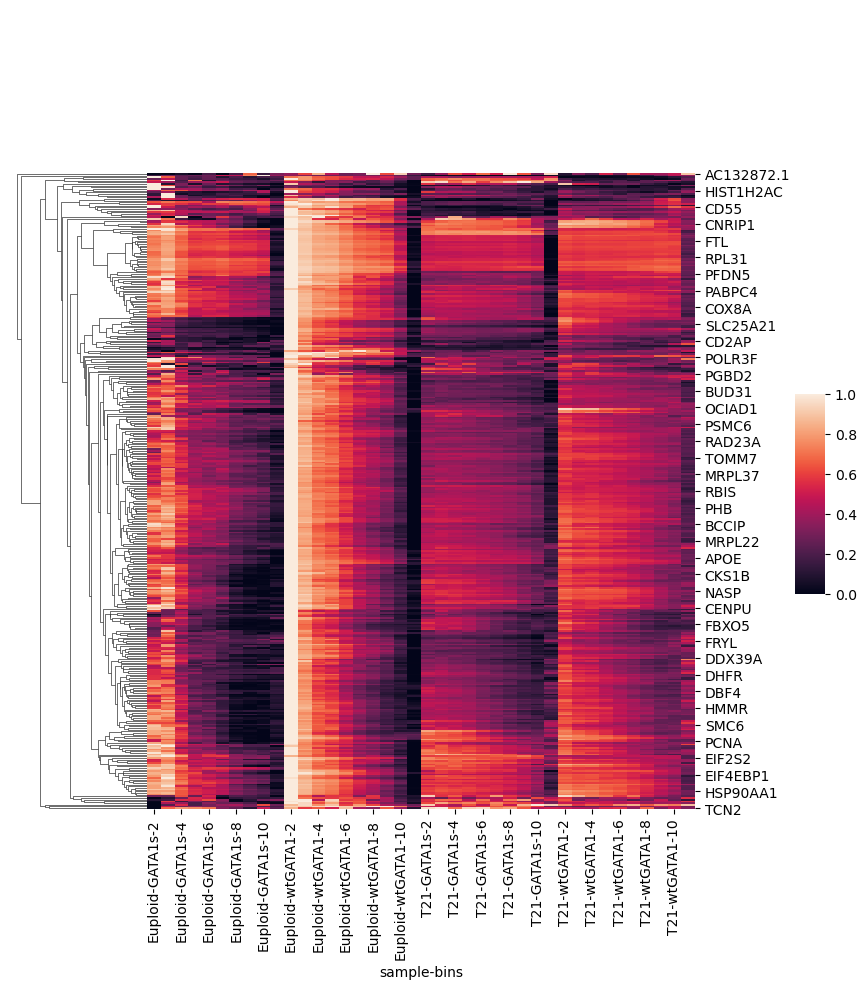

In [ ]:
p = sns.clustermap(hdata.T, col_cluster=False, standard_scale=0)
p.fig.subplots_adjust(right=0.7)
p.ax_cbar.set_position((0.8, .4, .03, .2))
plt.savefig("figures/timecourse-d7911-renamed-Ery-DEGs-heatmap.png")